# Class 23: Fourier Transforms

Ch. 7, sections 1-2: Fourier Transforms 
- Fourier series
- Discrete Fourier transforms

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import numpy as np
import cmath 
import matplotlib.pyplot as plt

### Discrete Fourier Transforms 

Write a function that calculates the discrete Fourier transform (DFT) given by: 

$$ c_k = \sum_{n=0}^{N-1}y_n \exp\left(-i \frac{2\pi kn}{N}\right) $$

In [2]:
def DFT(y): #where y is a list or array of length N filled with sample points
    #determine the number of sample points
    N = len(y)

    #create an array for all the fourier coefficients 
    #assume the function is real

    c = np.zeros(N//2 + 1,complex) #we only need to deal with half of the Ns, it needs to be an integer, and inclusive of the "middle" point if it is odd

    #loop through to calculate the coefficients ck
    for k in range(len(c)):
        ck = 0
        for n in range(N):
            ck += y[n]*cmath.exp(-2j*np.pi*k*n/N) #cmath.exp allows for complex exponential well
        c[k] = ck
    return c


### Apply this function to `pitch.txt`

**(1)** First, read in and plot the data from `pitch.txt`

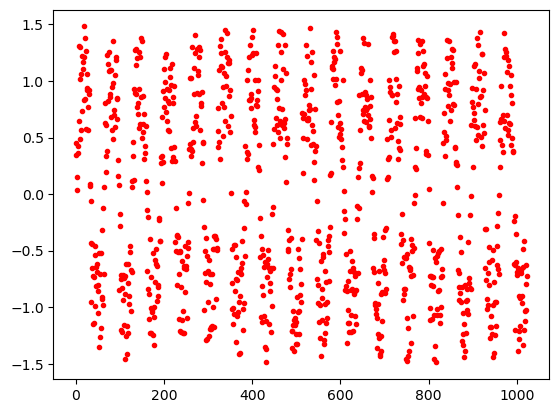

In [3]:
pitch = np.loadtxt('pitch.txt',float) #pitch is a 1d array

plt.plot(pitch,'r.')
plt.show()

**(2)** Apply your DFT function and plot the results 

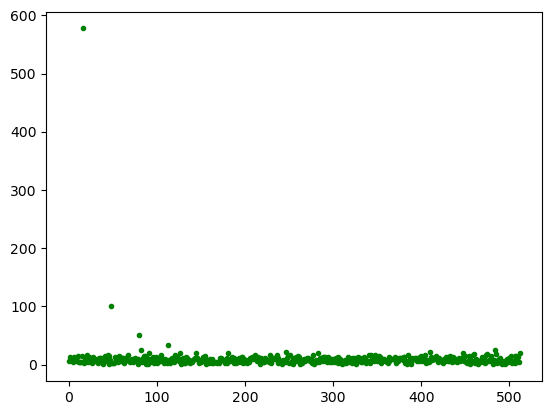

In [4]:
cpitch = DFT(pitch) #an array of our coefficients ck

plt.plot(np.abs(cpitch),'g.')
plt.show()



### Exercise 7.2: Detecting Periodicity (part)

In the on-line resources there is a file called `sunspots.txt`, which contains the observed number of sunspots on the Sun for each month since January 1749. The file contains two columns of numbers, the first representing the month and the second being the sunspot number.

a) Write a program that reads the data in the file and makes a graph of sunspots as a function of time. You should see that the number of sunspots has fluctuated on a regular cycle for as long as observations have been recorded. Make an estimate of the length of the cycle in months.

b) Modify your program to calculate the Fourier transform of the sunspot data and then make a graph of the magnitude squared $|c_k|^2$ of the Fourier coefficients as a function of $k$—also called the power spectrum of the sunspot signal. You should see that there is a noticeable peak in the power spectrum at a nonzero value of $k$. The appearance of this peak tells us that there is one frequency in the Fourier series that has a higher amplitude than the others around it—meaning that there is a large sine-wave term with this frequency, which corresponds to the periodic wave you can see in the original data.

c) Find the approximate value of $k$ to which the peak corresponds. What is the period of the sine wave with this value of $k$? You should find that the period corresponds roughly to the length of the cycle that you estimated in part (a).

This kind of Fourier analysis is a sensitive method for detecting periodicity in signals. Even in cases where it is not clear to the eye that there is a periodic component to a signal, it may still be possible to find one using a Fourier transform.

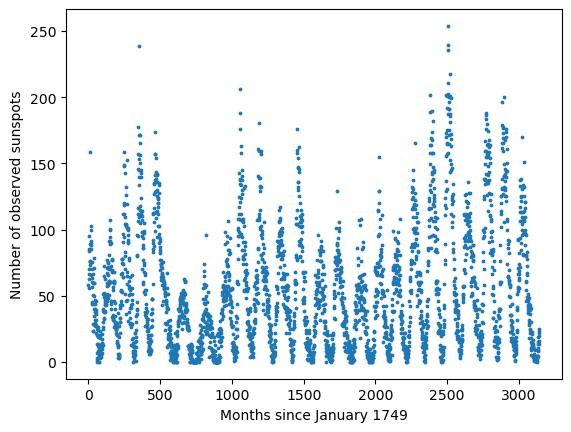

In [5]:
## part a

sunspots = np.loadtxt('sunspots.txt',float)

#separate the data
months = sunspots[:,0]
numspots = sunspots[:,1]

plt.scatter(months,numspots,s=3)
plt.xlabel('Months since January 1749')
plt.ylabel('Number of observed sunspots')
plt.show()



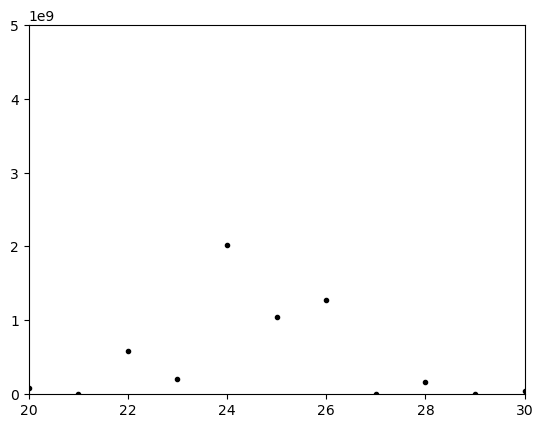

In [7]:
## part b - apply DFT function and calculate period 

ck_sunspots = DFT(numspots) #only the "y points" of the data


plt.plot(np.abs(ck_sunspots)**2,'k.')
plt.xlim(20,30)
plt.ylim(0,5e9)
plt.show()



In [8]:
## part (c)

#from the above graph, we saw a peak at k=24
k = 24

T = len(numspots)/k #period = N/k

print('The period is',T,'months.')




The period is 130.95833333333334 months.
